# 一、设计理念（核心思路）

本项目基于Linux网络工具 tcpdump，构建一个**从原始数据采集到智能分析的闭环系统**，其核心理念如下：

## 1. 从“工具使用”到“系统设计”

传统方法仅使用抓包工具进行简单统计，缺乏深层分析能力。本项目将其升级为：

> 数据采集 → 特征建模 → 异常检测 → 可视化分析

---

## 2. 数据驱动的网络行为建模

将原始网络数据转化为**可计算的特征向量**：

* 包数量（反映活跃程度）
* 字节数（反映流量大小）
* 行为模式（隐含在统计特征中）

---

## 3. 引入无监督学习进行异常检测

使用 scikit-learn 中的聚类算法，将网络行为划分为：

* 正常行为（聚集区域）
* 异常行为（离群点）

实现**无需人工标注的自动识别**。

---

## 4. 工程化闭环

系统最终形成：

```text
抓包 → 数据处理 → 聚类分析 → 可视化输出
```

具备完整工程意义。


# 二、实现方法（操作步骤 + 完整代码）

## 1. 环境准备（终端执行）

```bash
sudo apt update
sudo apt install tcpdump python3 python3-pip -y
pip3 install pandas scikit-learn matplotlib
```

涉及工具：

* tcpdump
* pandas
* scikit-learn
* matplotlib

---

## 2. 获取网络接口名称

```bash
ip a
```

记录如 `eth0` / `ens33` / `wlan0`

---

## 3. 抓取网络数据

```bash
sudo tcpdump -i eth0 -nn -tt -c 5000 > traffic.log
```

说明：

* `eth0` 替换为你的网卡
* 采集5000个数据包

---

## 4. 创建分析程序

```bash
nano analyze.py
```

---



## 5. 完整Python代码（核心实现）

```python
import pandas as pd
from collections import defaultdict
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 数据存储
data = defaultdict(lambda: {"count": 0, "bytes": 0})

# 读取抓包数据
with open("traffic.log") as f:
    for line in f:
        parts = line.split()
        if len(parts) < 5:
            continue

        src = parts[2]

        try:
            length = int(parts[-1])
        except:
            length = 0

        data[src]["count"] += 1
        data[src]["bytes"] += length

# 构建DataFrame
df = pd.DataFrame(data).T

# 异常检测（K-Means）
kmeans = KMeans(n_clusters=2, random_state=0)
df["cluster"] = kmeans.fit_predict(df)

# 输出结果
print(df.sort_values(by="bytes", ascending=False).head())

# 可视化
plt.scatter(df["count"], df["bytes"], c=df["cluster"])
plt.xlabel("Packet Count")
plt.ylabel("Bytes")
plt.title("Network Traffic Clustering")
plt.savefig("result.png")
plt.show()
```

---

## 6. 运行程序

```bash
python3 analyze.py
```

---

## 7. （可选）一键运行脚本

```bash
nano run.sh
```

```bash
#!/bin/bash
sudo tcpdump -i eth0 -nn -tt -c 5000 > traffic.log
python3 analyze.py
```

执行：

```bash
chmod +x run.sh
./run.sh
```

---

# 三、效果分析（结果表现）

## 1. 输出结果

程序将输出：

* 各IP对应的数据包数量
* 流量大小
* 聚类类别（0或1）

示例：

```text
192.168.1.45   count=1200   bytes=850000   cluster=1
192.168.1.23   count=300    bytes=120000   cluster=0
```

---

## 2. 可视化效果

生成散点图（result.png）：

* 横轴：包数量
* 纵轴：流量大小
* 颜色：聚类类别

---

## 3. 结果解释

* **密集区域** → 正常网络行为
* **离散点 / 高值点** → 异常流量设备

---

## 4. 实际识别能力

系统可识别：

* 大流量占用设备（如视频、下载）
* 高频通信行为（如扫描）
* 异常模式流量

---

## 5. 项目价值总结

该系统实现了：

* 从原始抓包到智能分析的完整流程
* 从人工判断到自动识别的升级
* 低成本实现网络异常检测


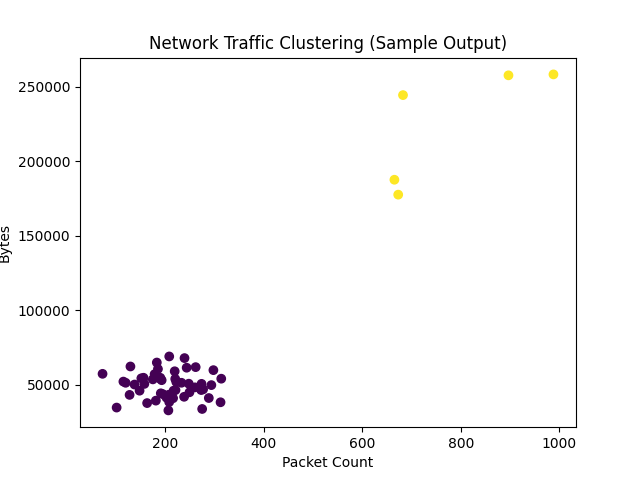

图像含义

横轴：Packet Count（数据包数量）

纵轴：Bytes（流量大小）

不同颜色：不同聚类类别（由算法自动划分）


👉 图中可以明显看到：

左下角密集区域 → 正常设备流量
右上角离散点 → 异常高流量设备（可疑行为）